Accuracy: 1.0
[[ 1  0  0]
 [ 0 21  0]
 [ 0  0 23]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        23

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



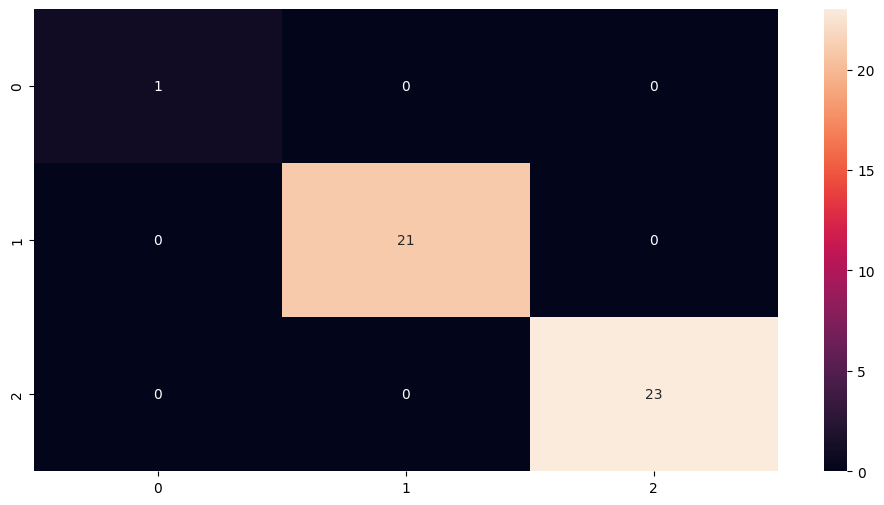

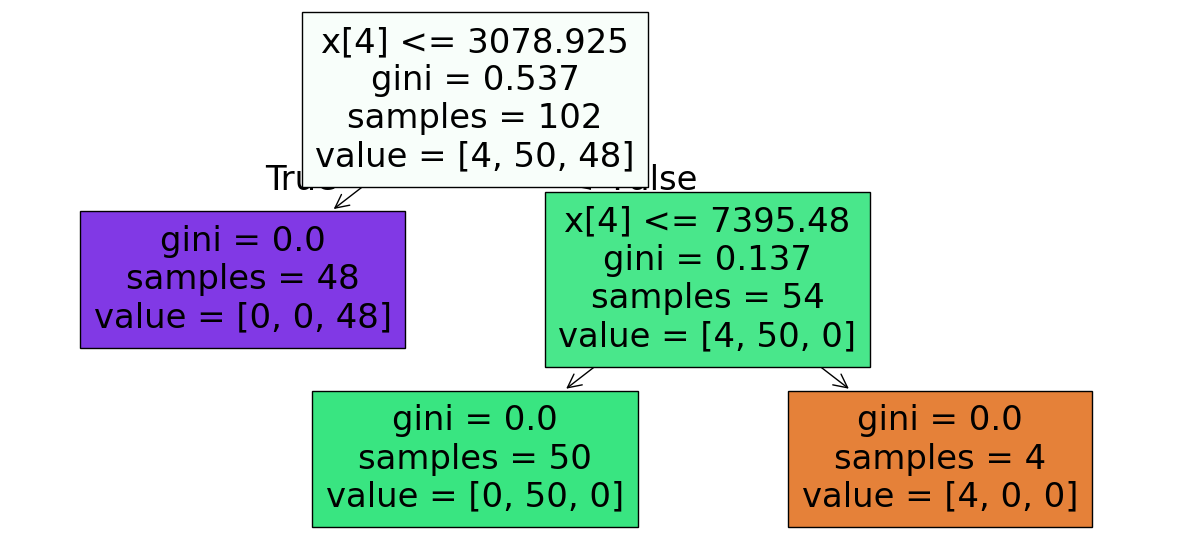

Interpretation: High accuracy but may overfit due to single tree.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/sales_data_sample.csv",encoding='latin1')
df = df.dropna()

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test,y_pred)

print("Accuracy:",acc)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

plt.figure(figsize=(12,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.show()

plt.figure(figsize=(15,7))
plot_tree(model,filled=True)
plt.show()

if acc>0.9:
    print("Interpretation: High accuracy but may overfit due to single tree.")
elif acc>0.8:
    print("Interpretation: Good performance but risk of overfitting exists.")
else:
    print("Interpretation: Model performance is weak.")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Params: {'max_depth': 5, 'min_samples_split': 2}
Accuracy: 1.0
[[ 1  0  0]
 [ 0 21  0]
 [ 0  0 23]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        23

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



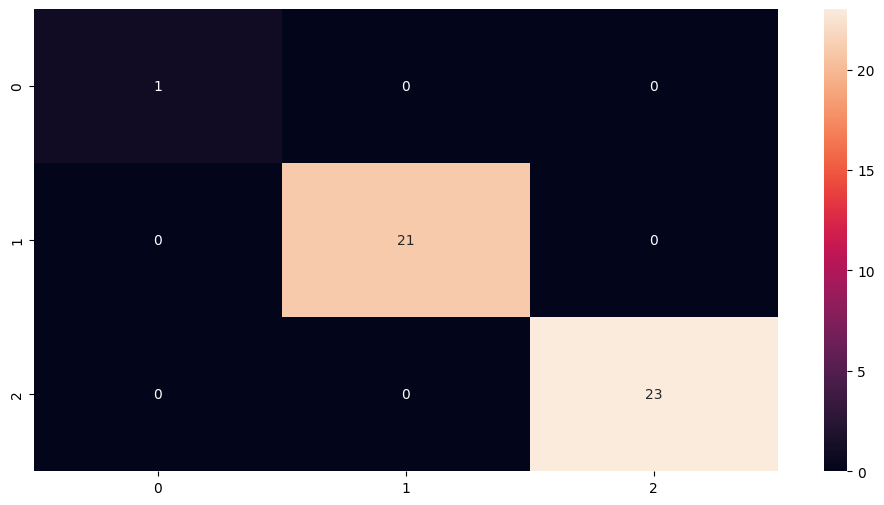

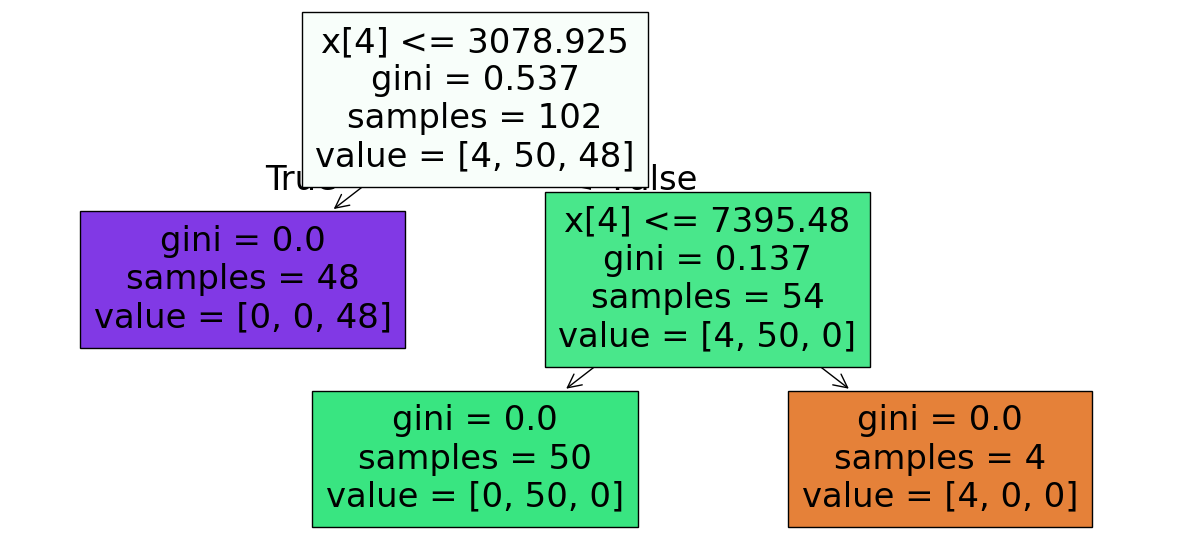

Interpretation: Tuning reduces overfitting and improves generalization.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/sales_data_sample.csv",encoding='latin1')
df = df.dropna()

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

params = {'max_depth':[5,10,20,None],'min_samples_split':[2,5,10]}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),params,cv=5)
grid.fit(X_train,y_train)

model = grid.best_estimator_

y_pred = model.predict(X_test)

acc = accuracy_score(y_test,y_pred)

print("Best Params:",grid.best_params_)
print("Accuracy:",acc)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

plt.figure(figsize=(12,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.show()

plt.figure(figsize=(15,7))
plot_tree(model,filled=True)
plt.show()

print("Interpretation: Tuning reduces overfitting and improves generalization.")

Accuracy: 0.9777777777777777
[[ 0  1  0]
 [ 0 21  0]
 [ 0  0 23]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.95      1.00      0.98        21
           2       1.00      1.00      1.00        23

    accuracy                           0.98        45
   macro avg       0.65      0.67      0.66        45
weighted avg       0.96      0.98      0.97        45



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


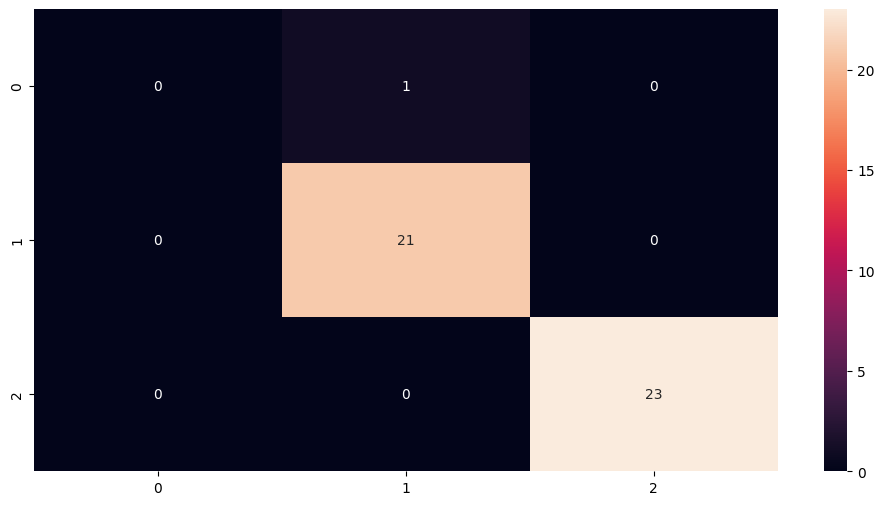

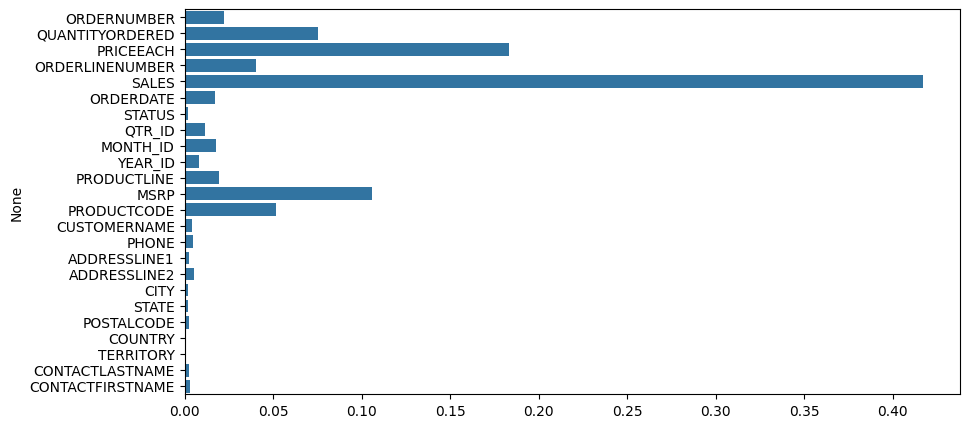

Interpretation: High accuracy with reduced overfitting due to ensemble learning.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/sales_data_sample.csv",encoding='latin1')
df = df.dropna()

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test,y_pred)

print("Accuracy:",acc)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

plt.figure(figsize=(12,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.show()

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances,y=features)
plt.show()

if acc>0.9:
    print("Interpretation: High accuracy with reduced overfitting due to ensemble learning.")
else:
    print("Interpretation: Performance can be improved with tuning.")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Params: {'max_depth': 5, 'n_estimators': 50}
Accuracy: 0.9777777777777777
[[ 0  1  0]
 [ 0 21  0]
 [ 0  0 23]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.95      1.00      0.98        21
           2       1.00      1.00      1.00        23

    accuracy                           0.98        45
   macro avg       0.65      0.67      0.66        45
weighted avg       0.96      0.98      0.97        45



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


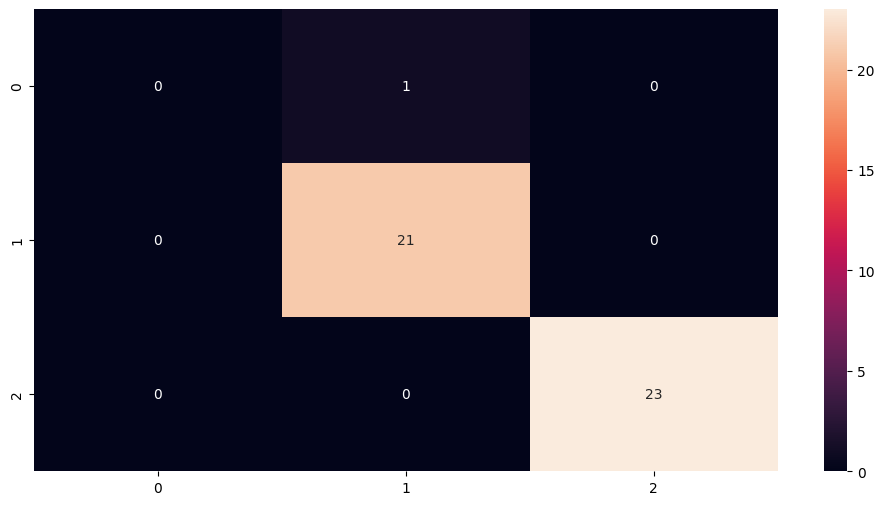

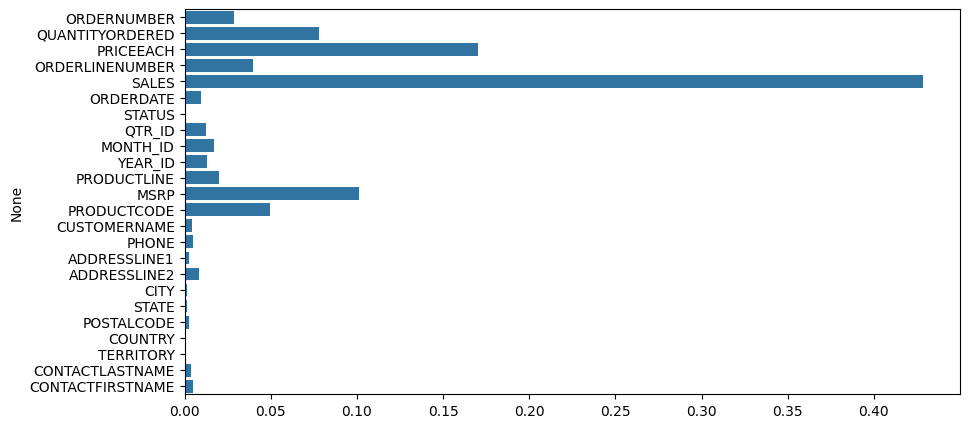

Interpretation: Tuned Random Forest gives best accuracy and stability with reduced overfitting.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/sales_data_sample.csv",encoding='latin1')
df = df.dropna()

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

params = {'n_estimators':[50,100,200],'max_depth':[5,10,20,None]}

grid = GridSearchCV(RandomForestClassifier(random_state=42),params,cv=5)
grid.fit(X_train,y_train)

model = grid.best_estimator_

y_pred = model.predict(X_test)

acc = accuracy_score(y_test,y_pred)

print("Best Params:",grid.best_params_)
print("Accuracy:",acc)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

plt.figure(figsize=(12,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.show()

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances,y=features)
plt.show()

print("Interpretation: Tuned Random Forest gives best accuracy and stability with reduced overfitting.")